# Implementación de Regresión Logística con PyTorch

<a href="https://colab.research.google.com/github/andrescastro-itm/pytorch_resources/blob/main/4_RegresionLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En este notebook, implementaremos una regresión logística utilizando PyTorch. Seguiremos estos pasos:

1. Generar un conjunto de datos sintético binario
2. Preparar los datos para el entrenamiento
3. Definir el modelo de regresión logística usando la API de PyTorch
4. Implementar el proceso de entrenamiento
5. Evaluar el modelo
6. Visualizar los resultados

In [1]:
# Importamos las bibliotecas necesarias
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Configuramos la semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

# Configuramos matplotlib
%matplotlib inline
plt.style.use('ggplot')

## 1. Generación del Conjunto de Datos Sintético

Crearemos un conjunto de datos binario simple con dos características. Los datos tendrán dos clases que serán parcialmente separables.

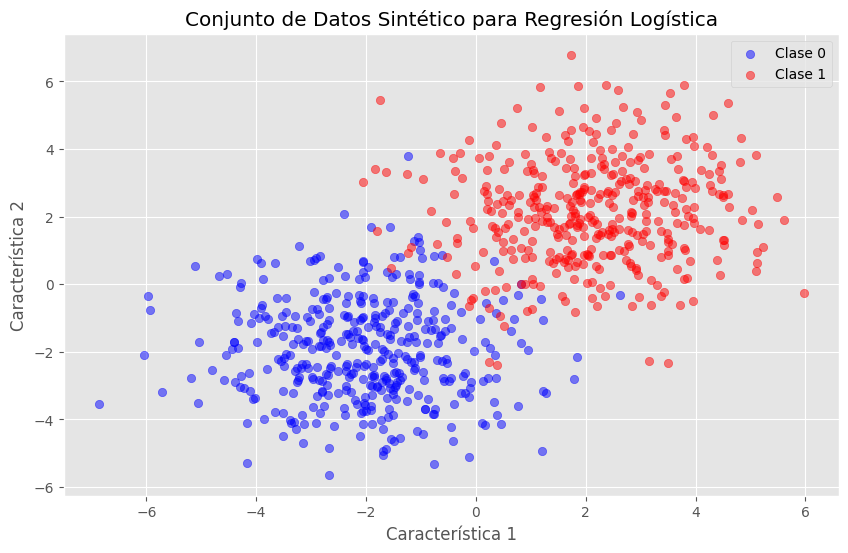

Dimensiones del conjunto de entrenamiento: (800, 2)
Dimensiones del conjunto de prueba: (200, 2)


In [2]:
def generar_dataset_sintetico(num_muestras=1000, test_size=0.2):
    # Generamos puntos para la clase 0
    num_clase_0 = num_muestras // 2
    X_0 = np.random.randn(num_clase_0, 2) * 1.5 + np.array([-2.0, -2.0])
    y_0 = np.zeros(num_clase_0)
    
    # Generamos puntos para la clase 1
    num_clase_1 = num_muestras - num_clase_0
    X_1 = np.random.randn(num_clase_1, 2) * 1.5 + np.array([2.0, 2.0])
    y_1 = np.ones(num_clase_1)
    
    # Combinamos los datos
    X = np.vstack([X_0, X_1])
    y = np.hstack([y_0, y_1])
    
    # Dividimos en conjuntos de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    return X_train, X_test, y_train, y_test

# Generamos los datos
X_train, X_test, y_train, y_test = generar_dataset_sintetico(num_muestras=1000)

# Visualizamos los datos
plt.figure(figsize=(10, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='blue', alpha=0.5, label='Clase 0')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='red', alpha=0.5, label='Clase 1')
plt.title('Conjunto de Datos Sintético para Regresión Logística')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.grid(True)
plt.show()

print(f"Dimensiones del conjunto de entrenamiento: {X_train.shape}")
print(f"Dimensiones del conjunto de prueba: {X_test.shape}")

## 2. Preparación de los Datos para PyTorch

Convertiremos nuestros datos NumPy a tensores de PyTorch para poder utilizarlos en nuestro modelo.

In [3]:
# Convertimos los datos a tensores de PyTorch
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Reshapeamos y para que tenga la forma correcta para BCELoss
y_train_tensor = y_train_tensor.view(-1, 1)
y_test_tensor = y_test_tensor.view(-1, 1)

print(f"Formas de los tensores:")
print(f"X_train_tensor: {X_train_tensor.shape}")
print(f"y_train_tensor: {y_train_tensor.shape}")
print(f"X_test_tensor: {X_test_tensor.shape}")
print(f"y_test_tensor: {y_test_tensor.shape}")

Formas de los tensores:
X_train_tensor: torch.Size([800, 2])
y_train_tensor: torch.Size([800, 1])
X_test_tensor: torch.Size([200, 2])
y_test_tensor: torch.Size([200, 1])


## 3. Definición del Modelo de Regresión Logística

Utilizaremos la API de PyTorch para definir nuestro modelo de regresión logística como una clase que hereda de `nn.Module`.

In [4]:
class RegresionLogistica(nn.Module):
    def __init__(self, num_features):
        super(RegresionLogistica, self).__init__()
        # Creamos una capa lineal: y = Wx + b
        self.linear = nn.Linear(num_features, 1)
        # La función sigmoid se aplicará en el forward pass
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Aplicamos la transformación lineal
        logits = self.linear(x)
        # Aplicamos la función sigmoid para obtener probabilidades
        probas = self.sigmoid(logits)
        return probas
    
# Instanciamos el modelo
num_features = X_train.shape[1]  # Número de características
modelo = RegresionLogistica(num_features)

# Imprimimos la estructura del modelo
print(modelo)

RegresionLogistica(
  (linear): Linear(in_features=2, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## 4. Implementación del Proceso de Entrenamiento

Ahora implementaremos el proceso de entrenamiento del modelo. Definiremos la función de pérdida (Binary Cross Entropy) y el optimizador (SGD).

Época [100/1000], Pérdida: 0.0748
Época [200/1000], Pérdida: 0.0745
Época [300/1000], Pérdida: 0.0745
Época [400/1000], Pérdida: 0.0745
Época [500/1000], Pérdida: 0.0745
Época [600/1000], Pérdida: 0.0745
Época [700/1000], Pérdida: 0.0745
Época [800/1000], Pérdida: 0.0745
Época [900/1000], Pérdida: 0.0745
Época [1000/1000], Pérdida: 0.0745


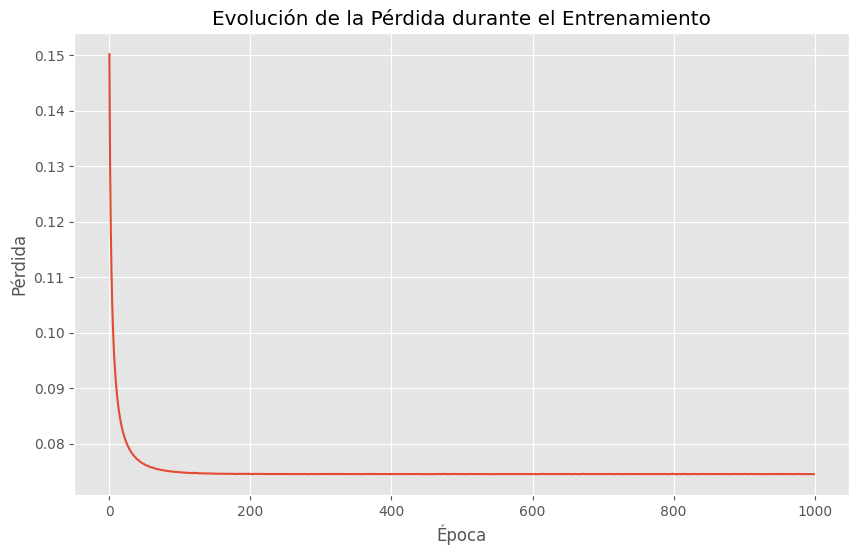

In [5]:
# Definimos la función de pérdida y el optimizador
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.SGD(modelo.parameters(), lr=0.1)  # Descenso de Gradiente Estocástico

# Parámetros de entrenamiento
num_epochs = 1000
batch_size = 100
batches_per_epoch = len(X_train_tensor) // batch_size
losses = []  # Para guardar el historial de pérdida

# Entrenamiento del modelo
for epoch in range(num_epochs):
    # Barajamos los datos en cada época
    indices = torch.randperm(len(X_train_tensor))
    X_train_shuffled = X_train_tensor[indices]
    y_train_shuffled = y_train_tensor[indices]
    
    epoch_loss = 0.0
    
    # Entrenamiento por lotes
    for i in range(batches_per_epoch):
        # Obtenemos el lote actual
        start_idx = i * batch_size
        end_idx = start_idx + batch_size
        
        X_batch = X_train_shuffled[start_idx:end_idx]
        y_batch = y_train_shuffled[start_idx:end_idx]
        
        # Forward pass
        y_pred = modelo(X_batch)
        
        # Cálculo de la pérdida
        loss = criterion(y_pred, y_batch)
        epoch_loss += loss.item()
        
        # Reiniciamos los gradientes
        optimizer.zero_grad()
        
        # Backward pass
        loss.backward()
        
        # Actualización de parámetros
        optimizer.step()
    
    # Guardamos la pérdida promedio de la época
    avg_epoch_loss = epoch_loss / batches_per_epoch
    losses.append(avg_epoch_loss)
    
    # Imprimimos el progreso cada 100 épocas
    if (epoch + 1) % 100 == 0:
        print(f'Época [{epoch+1}/{num_epochs}], Pérdida: {avg_epoch_loss:.4f}')

# Graficamos la evolución de la pérdida
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Evolución de la Pérdida durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True)
plt.show()

## 5. Evaluación del Modelo

Evaluaremos el rendimiento del modelo en el conjunto de prueba calculando la exactitud (accuracy) y otras métricas.

In [6]:
# Evaluamos el modelo
modelo.eval()  # Cambiamos a modo evaluación

with torch.no_grad():  # No necesitamos calcular gradientes durante la evaluación
    # Obtenemos las predicciones para el conjunto de prueba
    y_pred_proba = modelo(X_test_tensor)
    y_pred = (y_pred_proba >= 0.5).float()  # Umbral 0.5 para clasificación binaria
    
    # Calculamos la exactitud (accuracy)
    accuracy = (y_pred == y_test_tensor).float().mean()
    
    # Calculamos pérdida en el conjunto de prueba
    test_loss = criterion(y_pred_proba, y_test_tensor)

print(f"Pérdida en el conjunto de prueba: {test_loss.item():.4f}")
print(f"Exactitud (Accuracy) en el conjunto de prueba: {accuracy.item():.4f}")

# Calculamos métricas adicionales (confusión, precisión, recall, f1)
y_pred_np = y_pred.numpy().flatten()
y_test_np = y_test_tensor.numpy().flatten()

# Calculamos la matriz de confusión manualmente
tp = np.sum((y_pred_np == 1) & (y_test_np == 1))
fp = np.sum((y_pred_np == 1) & (y_test_np == 0))
tn = np.sum((y_pred_np == 0) & (y_test_np == 0))
fn = np.sum((y_pred_np == 0) & (y_test_np == 1))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nMatriz de Confusión:")
print(f"Verdaderos Positivos (TP): {tp}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Negativos (FN): {fn}")

print(f"\nMétricas adicionales:")
print(f"Precisión: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Pérdida en el conjunto de prueba: 0.0732
Exactitud (Accuracy) en el conjunto de prueba: 0.9700

Matriz de Confusión:
Verdaderos Positivos (TP): 101
Falsos Positivos (FP): 3
Verdaderos Negativos (TN): 93
Falsos Negativos (FN): 3

Métricas adicionales:
Precisión: 0.9712
Recall: 0.9712
F1-Score: 0.9712


## 6. Visualización de la Frontera de Decisión

Visualizaremos la frontera de decisión aprendida por nuestro modelo.

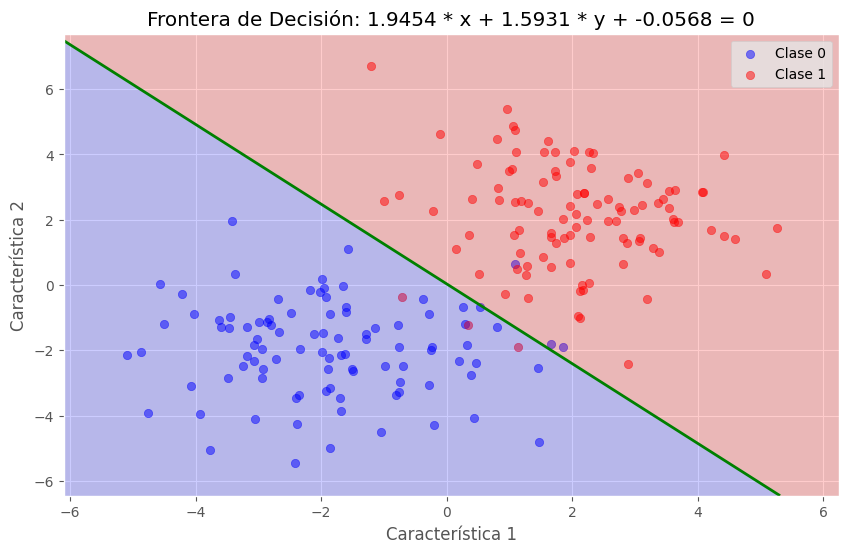

In [7]:
# Obtenemos los pesos y el sesgo del modelo
w = modelo.linear.weight.data.numpy().flatten()
b = modelo.linear.bias.data.numpy().item()

# Visualizamos la frontera de decisión
plt.figure(figsize=(10, 6))

# Mostramos los datos de prueba
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], color='blue', alpha=0.5, label='Clase 0')
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color='red', alpha=0.5, label='Clase 1')

# Creamos la malla para graficar la frontera de decisión
x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Evaluamos el modelo en todos los puntos de la malla
modelo.eval()
with torch.no_grad():
    Z = modelo(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.numpy().reshape(xx.shape)

# Graficamos el contorno de decisión (probabilidad = 0.5)
plt.contour(xx, yy, Z, levels=[0.5], colors='green', linewidths=2)
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, colors=['blue', 'red'])

# Ecuación de la frontera de decisión
equation = f"{w[0]:.4f} * x + {w[1]:.4f} * y + {b:.4f} = 0"
plt.title(f'Frontera de Decisión: {equation}')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.grid(True)
plt.show()

## 7. Análisis del Modelo Entrenado

Analicemos los pesos y sesgos aprendidos por nuestro modelo.

In [8]:
# Extraemos los parámetros del modelo
w = modelo.linear.weight.data.numpy().flatten()
b = modelo.linear.bias.data.numpy().item()

print("Parámetros del modelo aprendido:")
print(f"Peso para característica 1: {w[0]:.6f}")
print(f"Peso para característica 2: {w[1]:.6f}")
print(f"Sesgo (bias): {b:.6f}")

# Ecuación del modelo
print("\nEcuación del modelo:")
print(f"p(y=1) = sigmoid({w[0]:.4f} * x1 + {w[1]:.4f} * x2 + {b:.4f})")

# Análisis de importancia de características
abs_weights = np.abs(w)
total_importance = np.sum(abs_weights)
relative_importance = abs_weights / total_importance

print("\nImportancia relativa de características:")
print(f"Característica 1: {relative_importance[0]*100:.2f}%")
print(f"Característica 2: {relative_importance[1]*100:.2f}%")

Parámetros del modelo aprendido:
Peso para característica 1: 1.945393
Peso para característica 2: 1.593147
Sesgo (bias): -0.056825

Ecuación del modelo:
p(y=1) = sigmoid(1.9454 * x1 + 1.5931 * x2 + -0.0568)

Importancia relativa de características:
Característica 1: 54.98%
Característica 2: 45.02%


## 8. Predicciones con el Modelo

Ahora haremos algunas predicciones con nuestro modelo para nuevos datos.

Predicciones para nuevos puntos:
Punto 1: [-2.0, -2.0] → Probabilidad: 0.0008, Clase: 0
Punto 2: [2.0, 2.0] → Probabilidad: 0.9991, Clase: 1
Punto 3: [0.0, 0.0] → Probabilidad: 0.4858, Clase: 0
Punto 4: [-1.0, 2.0] → Probabilidad: 0.7657, Clase: 1
Punto 5: [2.0, -1.0] → Probabilidad: 0.9039, Clase: 1


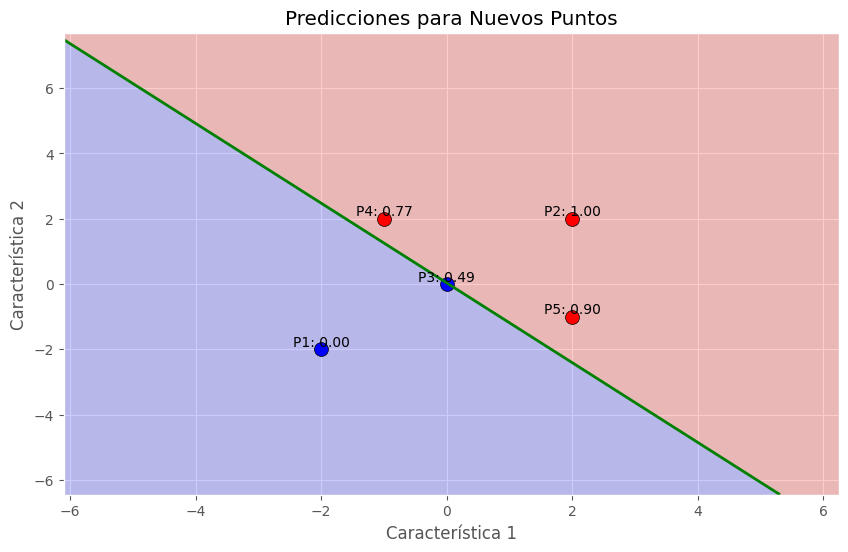

In [9]:
# Función para realizar predicciones
def predict(modelo, x):
    modelo.eval()
    with torch.no_grad():
        x_tensor = torch.FloatTensor(x)
        prob = modelo(x_tensor).item()
        clase = 1 if prob >= 0.5 else 0
        return prob, clase

# Algunos puntos para probar
puntos_prueba = [
    [-2.0, -2.0],  # Debería ser clase 0
    [2.0, 2.0],    # Debería ser clase 1
    [0.0, 0.0],    # Punto cerca de la frontera
    [-1.0, 2.0],   # Punto mixto
    [2.0, -1.0]    # Punto mixto
]

print("Predicciones para nuevos puntos:")
for i, punto in enumerate(puntos_prueba):
    prob, clase = predict(modelo, punto)
    print(f"Punto {i+1}: {punto} → Probabilidad: {prob:.4f}, Clase: {clase}")

# Visualización de estos puntos y sus predicciones
plt.figure(figsize=(10, 6))

# Graficamos la frontera de decisión
plt.contour(xx, yy, Z, levels=[0.5], colors='green', linewidths=2)
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, colors=['blue', 'red'])

# Graficamos los puntos de prueba
for i, punto in enumerate(puntos_prueba):
    prob, clase = predict(modelo, punto)
    color = 'red' if clase == 1 else 'blue'
    plt.scatter(punto[0], punto[1], color=color, s=100, edgecolor='black')
    plt.text(punto[0], punto[1], f"P{i+1}: {prob:.2f}", fontsize=10, ha='center', va='bottom')

plt.title('Predicciones para Nuevos Puntos')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.grid(True)
plt.show()

## 9. Conclusiones

En este notebook, hemos implementado un modelo de regresión logística utilizando PyTorch. Hemos seguido estos pasos:

1. **Generación de datos**: Creamos un conjunto de datos sintético con dos clases y dos características.
2. **Preparación**: Convertimos los datos a tensores de PyTorch.
3. **Modelado**: Definimos una clase para nuestro modelo utilizando la API de PyTorch.
4. **Entrenamiento**: Implementamos el proceso de entrenamiento con batches y SGD.
5. **Evaluación**: Calculamos métricas de rendimiento sobre el conjunto de prueba.
6. **Visualización**: Mostramos la frontera de decisión aprendida por el modelo.
7. **Análisis**: Examinamos los parámetros aprendidos y su interpretación.
8. **Predicción**: Utilizamos el modelo para predecir nuevos puntos.

La regresión logística es un algoritmo fundamental para problemas de clasificación binaria, y PyTorch nos permite implementarlo de manera eficiente y flexible.